## Импорт библиотек и датасета

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import math

from tqdm.auto import tqdm
from datasets import load_dataset  # datasets-2.11.0
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize, sent_tokenize
from sklearn.model_selection import train_test_split
import nltk

import string
import re
from typing import List

import random
random.seed(42)

import seaborn
seaborn.set(palette='summer')

In [2]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Maxim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
dataset = load_dataset("IlyaGusev/gazeta")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'summary', 'title', 'date', 'url'],
        num_rows: 60964
    })
    validation: Dataset({
        features: ['text', 'summary', 'title', 'date', 'url'],
        num_rows: 6369
    })
    test: Dataset({
        features: ['text', 'summary', 'title', 'date', 'url'],
        num_rows: 6793
    })
})

## Глобальные переменные

In [5]:
MAX_LEN_TOKENS = 25
MIN_WORDS_COUNT = 5
MAX_SAMPLES_COUNT = 2000
HIDDEN_DIM = 256
BATCH_SIZE = 256
N_EPOCHS = 15

## Формирование словаря

In [6]:
def preprocessing(text):
    processed_text = re.sub(r"[^\w\s]", " ", text.lower(), flags=re.UNICODE)
    processed_text = re.sub(r"\s+", " ", processed_text).strip()
    return processed_text

In [7]:
words = {}
sentences  = []

for text in tqdm(dataset['train']['text'][:MAX_SAMPLES_COUNT]):
    for sent in sent_tokenize(text, language='russian'):
        processed_sent = preprocessing(sent)
        tokens = word_tokenize(processed_sent)
        if len(tokens) > MAX_LEN_TOKENS:
            continue
        for word in tokens:
            words[word] = words.get(word, 0) + 1
        sentences.append(tokens)

  0%|          | 0/2000 [00:00<?, ?it/s]

In [8]:
print(f"Количество предложений: {len(sentences)}")

Количество предложений: 56872


In [9]:
special_tokens = ["<unk>", "<bos>", "<eos>", "<pad>"]
vocab = set(special_tokens)

for word, cnt in words.items():
    if cnt >= MIN_WORDS_COUNT:
        vocab.add(word)

print(f"Размер словаря: {len(vocab)}")

Размер словаря: 19344


## Формировнаие даталоадера

In [10]:
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

In [11]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_idx = word2idx["<unk>"]
        self.bos_idx = word2idx["<bos>"]
        self.eos_idx = word2idx["<eos>"]
        self.pad_idx = word2idx["<pad>"]

    def __getitem__(self, idx: int):
        tokenized_sentence = [self.bos_idx] + [word2idx.get(word, self.unk_idx) for word in self.data[idx]] + [self.eos_idx]
        return tokenized_sentence

    def __len__(self):
        return len(self.data)

In [12]:
def collate_fn_with_padding(input_batch: List[List[int]], pad_idx=word2idx["<pad>"]) -> torch.Tensor:
    seq_lens = [len(seq) for seq in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        new_sequence = sequence.copy()
        for _ in range(max_seq_len - len(new_sequence)):
            new_sequence.append(pad_idx)
        new_batch.append(new_sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [13]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)

train_dataloader = DataLoader(train_dataset, collate_fn=collate_fn_with_padding, batch_size=BATCH_SIZE)
eval_dataloader = DataLoader(eval_dataset, collate_fn=collate_fn_with_padding, batch_size=BATCH_SIZE)

## Архитектура модели

In [14]:
class WordLM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)
        self.projection = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch) -> torch.Tensor:
        # Embedding → LSTM → Linear → Tanh → Dropout → Projection
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.lstm(embeddings)  # [batch_size, seq_len, hidden_dim]
        output = self.dropout(self.non_lin(self.linear(output)))  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(output)  # [batch_size, seq_len, vocab_size]
        return projection

## Train loop

In [15]:
def evaluate(model, criterion) -> float:
    model.eval()
    losses = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            losses.append(loss.item())

    mean_loss = sum(losses) / len(losses)
    perplexity = math.exp(mean_loss)

    return perplexity

In [16]:
model = WordLM(hidden_dim=HIDDEN_DIM, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2idx["<pad>"])
optimizer = torch.optim.Adam(model.parameters())

In [17]:
losses = []
perplexities = []

for epoch in range(N_EPOCHS):
    model.train()
    epoch_losses = []
    for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}'):
        optimizer.zero_grad()
        logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
        loss = criterion(logits, batch['target_ids'].flatten())
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
    losses.append(sum(epoch_losses) / len(epoch_losses))
    perplexities.append(evaluate(model, criterion))

Training epoch 0:   0%|          | 0/178 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/178 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/178 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/178 [00:00<?, ?it/s]

Training epoch 4:   0%|          | 0/178 [00:00<?, ?it/s]

...

Training epoch 10:   0%|          | 0/178 [00:00<?, ?it/s]

Training epoch 11:   0%|          | 0/178 [00:00<?, ?it/s]

Training epoch 12:   0%|          | 0/178 [00:00<?, ?it/s]

Training epoch 13:   0%|          | 0/178 [00:00<?, ?it/s]

Training epoch 14:   0%|          | 0/178 [00:00<?, ?it/s]

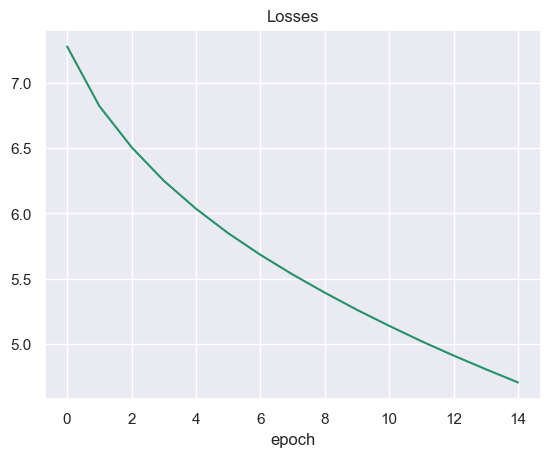

In [18]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

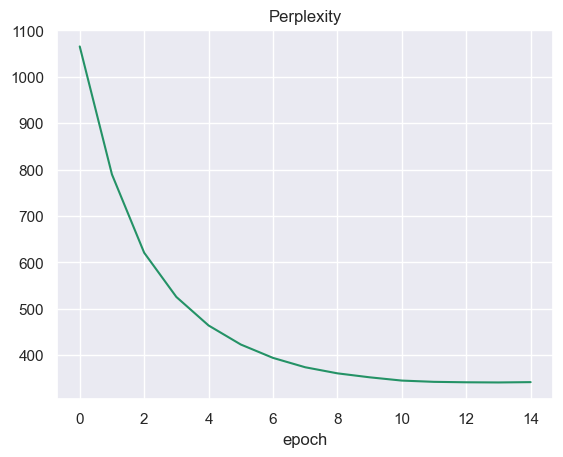

In [19]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

## Генерация

In [20]:
def generate_sequence(model, starting_seq: str, max_new_tokens: int = 30, top_k: int = 0):
    model.eval()
    device = next(model.parameters()).device
    unk_idx, bos_idx, eos_idx, pad_idx = [word2idx[special_token] for special_token in special_tokens]
    idxes = [bos_idx] + [word2idx.get(w, unk_idx) for w in word_tokenize(preprocessing(starting_seq))]
    input_idxes = torch.LongTensor(idxes).unsqueeze(0).to(device)  # [1, T]

    generated = []
    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(input_idxes)
            next_logits = logits[0, -1, :]
            for forbidden_idx in [unk_idx, bos_idx, pad_idx]:  # запрещенные токены в генерации
                next_logits[forbidden_idx] = -float("inf")
            if top_k > 0:
                v, _ = torch.topk(next_logits, top_k)
                next_logits[next_logits < v[-1]] = -float("inf")
            probs = torch.softmax(next_logits, dim=-1)
            next_idx = torch.multinomial(probs, 1).item()
            if next_idx == word2idx["<eos>"]:
                break
            generated.append(next_idx)
            input_idxes = torch.cat([input_idxes, torch.LongTensor([[next_idx]]).to(device)], dim=1)
    return " ".join([idx2word[i] for i in generated])


for seed in ["в россии", "президент заявил", "экономика"]:
    print(f">>> Затравка: {seed}")
    print(generate_sequence(model, seed, max_new_tokens=25, top_k=5), "\n")

>>> Затравка: в россии
в россии он не смог забить но и на самом деле на турнире 

>>> Затравка: президент заявил
что в ближайшее время было возбуждено в россии в лиге европы 

>>> Затравка: экономика
страны в москве и динамо в сша в среду вечером по сравнению с предыдущим годом в пятницу о том что в пятницу в москве где 

